In [ ]:
import numpy as np
from skimage import io, feature, color, draw, util, measure
import pandas as pdgit
import matplotlib.pyplot as plt

In [11]:
def detect_globular_rois(img_or_path, frame_index=0,
                         min_sigma=2, max_sigma=3, num_sigma=10,
                         threshold=0.05, overlap=0.5,
                         roi_radius=5, return_overlay=True):
    """
    Detect globular signals, draw circular ROIs around their centroids, and compute the sum intensity of pixels within.
    Args:
      img_or_path: 2D numpy array or path to a TIFF (can be a stack).
      frame_index: if img_or_path is a stack, index of frame to analyze.
      min_sigma, max_sigma, num_sigma, threshold, overlap: skimage.blob_log params.
      roi_radius: if None, radius = sqrt(2)*sigma for each blob; otherwise fixed radius in pixels.
      return_overlay: if True, also return an RGB image with circular ROI outlines.
    Returns:
      results: list of dicts: {'y':..., 'x':..., 'radius':..., 'sum':...}
      overlay (optional): RGB image (uint8) with red ROI outlines overlaid on the analyzed frame.
    """
    #Load in image file via...
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #If image is a stack (time lapse), work only on the designated frame.
    if img.ndim == 3:
        img2d = img[frame_index,:,:] #assuming (t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img2d = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    img_f = util.img_as_float(img2d)/np.max(img2d)

    #Apply skimage.feature function to detect blobs using Laplacian of Gaussian.
    #Returns an array with the centroid coords of each detected blob plus the sigma of each blob.
    blobs = feature.blob_log(img_f, min_sigma=min_sigma, max_sigma=max_sigma,
                             num_sigma=num_sigma, threshold=threshold, overlap=overlap)
    results = [] #initialize results list
    #Generate overlay variable
    overlay = None
    if return_overlay:
        rgb = color.gray2rgb(util.img_as_ubyte(img_f))
        overlay = rgb.copy()

    roi_ind=0#generate ROI index to distinguish unique ROIs
    #and then plot the ROIs for each detected blob
    for y, x, sigma in blobs: #for each detected blob in this frame...
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius #compute radius if none is set, otherwise use given value.
        r_int = int(max(1, round(r))) #radius must be an integer value of pixels greater than or equal to one. 
        rr, cc = draw.disk((y, x), r_int, shape=img_f.shape) #generate a disk mask about each given centroid.
        sum_intensity = float(img_f[rr, cc].sum()) #sum all pixel intensities within said disk.
        results.append({'ROI_ID': roi_ind,'frame':frame_index,'y': float(y), 'x': float(x), 'radius': float(r), 'sum': sum_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
        if return_overlay: #if overlay requested...
            pr, pc = draw.circle_perimeter(int(round(y)), int(round(x)), r_int, shape=overlay.shape[:2]) #draw the circular ROIs around the glob centroids.
            overlay[pr, pc] = (255, 0, 0) #sets color of ROI circles using RGB values.
        roi_ind+=1 #update ROI index
    if return_overlay==True: #if overlay requested...
        io.imshow(overlay)
        return pd.DataFrame.from_dict(results), overlay, rr, cc #return it with results
    return pd.DataFrame.from_dict(results) #else just return results. 

def roi_overlap(x1,y1,x2,y2, roi_radius=5, shape=(512,512)): 
    #Args: Two sets of x-y centroid coords, roi radius paramter, and total shape of masks (manually set to same as image)
    #Outputs: Fractional overlap between disks of equal radius centered about each centroid given.
    rr1, cc1 = draw.disk((y1, x1), roi_radius, shape=shape) #generate a disk mask about first centroid; variables contain pixel coords.
    dummy1=np.ones(shape) #dummy array for overlap measure
    dummy1[rr1,cc1]=-1 #set ROI pixel values to -1
    mask1=dummy1<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
    rr2, cc2 = draw.disk((y2, x2), roi_radius, shape=shape) #generate a disk mask about second centroid; variables contain pixel coords.
    dummy2=np.ones(shape) #dummy array for overlap measure
    dummy2[rr2,cc2]=-1 #set ROI pixel values to -1
    mask2=dummy2<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
    frac_olap=measure.intersection_coeff(mask1, mask2) #measure fractional overlap of Boolean ROI masks.
    return frac_olap

def analyze_budnecks(img_or_path):
    #Args: Image matrix or path to image file
    #Outputs: Dataframe consisting of roi id, frame number, x-y centroid coords, roi radius, and sum pixel intensity w/in roi
    #           for each detected globular signal within each frame of time lapse. 
    #Load in image file via...
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix
    # frame_dfs=[] #initialize list to append each frame's dataframe to.
    for i in range(img.shape[0]): #for each frame in timelapse...
        print('processing frame '+str(i)+'/'+str(np.max(img.shape[0])-1)) #optional frame by frame progress update
        if i==0: #for first frame, run initial globular detection and record ROIs and other metrics.
            running_list=detect_globular_rois(img, frame_index=i, return_overlay=False) #dataframe containing metrics for frame_0
        else: #for each frame past the first...
            cand_globs=detect_globular_rois(img, frame_index=i, return_overlay=False) #detect signal candidates in new frame.
            id_ind=1 #reset dummy id index value to use when assigning new, unique roi_ids to new signals.
            for cand_id in cand_globs['ROI_ID'].values: #for each candidate signal...
                cand_mask=cand_globs['ROI_ID'].values==cand_id #generate mask of its dataframe row
                candx, candy = cand_globs[cand_mask]['x'].values[0], cand_globs[cand_mask]['y'].values[0] #extract centroid coords of candidate ROI
                overlap_marker=False #the default is that each candidate will get its own new id unless sufficient overlap is detected
                for estb_id in running_list['ROI_ID'].values: #for each preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id #generate mask of its dataframe row
                    estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                    overlap=roi_overlap(candx,candy,estbx,estby) #calculate fractional overlap between candidate roi and each previous one.
                    if overlap>=0.5: #if overlap percentage is sufficient...
                        cand_globs.loc[cand_globs.ROI_ID==cand_id, 'ROI_ID']=estb_id #reassign candidate roi_id to that of established roi
                        overlap_marker=True #note that this candidate signal had sufficient overlap, and will not get a new, unique id.
                    else: #otherwise, move along through the rest of the established rois.
                        continue #move along, move along like i know ya do. move along, move along just to make it through
                if overlap_marker==False: #if insufficient overlap with preexisting signals...
                    cand_globs.loc[cand_globs.ROI_ID==cand_id, 'ROI_ID']=np.max(running_list['ROI_ID'].values)+id_ind #assign new id to accepted source
                    id_ind+=1 #update dummy id index to reflect new signal recognized.
            running_list=pd.concat([running_list,cand_globs], ignore_index=True) #append this frame's information to running list of dictionaries.
    # output_df=pd.DataFrame.from_dict(running_list) #transform all nested dictionaries into single dataframe object. 
    return running_list

def analyze_signal(df, plot_graph=False):
    #Args: Dataframe (or its corresponding file path) containing at least roi ids, frame numbers, and desired metric(s) to plot. Optional Boolean arg to generate plot.
    #Outputs: Dataframe containing roi ids and desired accompanying metrics. Optional plot.
    if plot_graph==True:
        plt.figure()
        for roi in np.unique(df['ROI_ID'].values)[10:20]: #for each detected roi in entire time lapse...
            mask=df['ROI_ID'].values==roi #create a mask to extract roi's rows
            roi_subset=df[mask] #apply mask
            plt.plot(5*roi_subset['frame'].values,roi_subset['sum'].values/np.max(roi_subset['sum'].values)) #plot normalized sum interior intensity as function of frame
            plt.scatter(5*roi_subset['frame'].values,roi_subset['sum'].values/np.max(roi_subset['sum'].values), label='Roi_'+str(roi))
        plt.xlabel('Time (min)')
        plt.ylabel('Normalized Sum Interior Pixel Intensity (AU)')
    return df

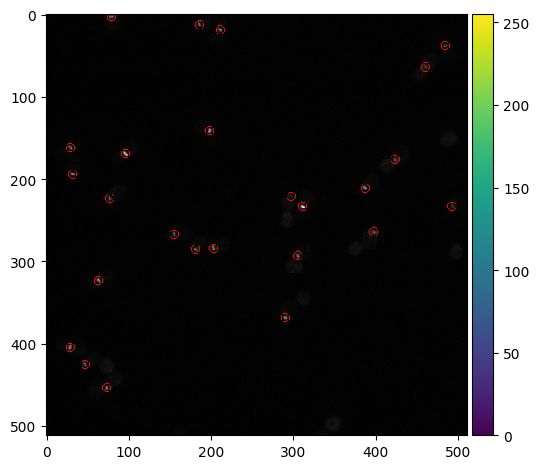

In [12]:
tdf,toverlay,trr,tcc=detect_globular_rois(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')

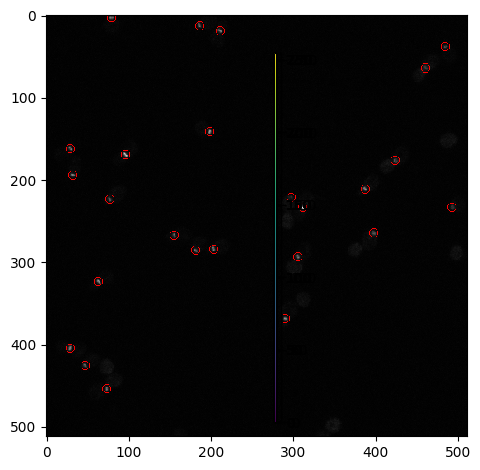

In [13]:
overlay_stack=[]
for frame in np.arange(0,21):
    tdf,toverlay,trr,tcc=detect_globular_rois(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif', frame_index=frame)
    overlay_stack.append(toverlay)
ind=0

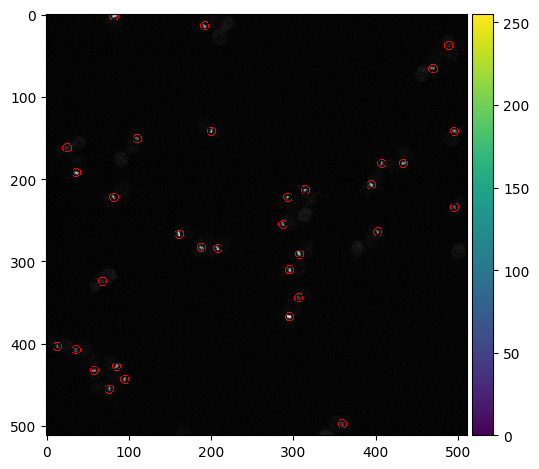

In [16]:
io.imshow(overlay_stack[ind])
ind+=3

9

In [11]:
# test=analyze_budnecks(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')

In [6]:
test.to_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_20251212.csv', index=False)

In [7]:
csv_20251212=pd.read_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_20251212.csv')

In [8]:
csv_20251212

,ROI_ID,frame,y,x,radius,sum
0,0,0,234.0,311.0,5.0,16.221384
1,1,0,170.0,96.0,5.0,13.303018
2,2,0,142.0,198.0,5.0,9.960070
3,3,0,195.0,32.0,5.0,8.966282
4,4,0,405.0,29.0,5.0,10.528395
...,...,...,...,...,...,...
793,93,21,81.0,465.0,5.0,4.212941
794,40,21,279.0,156.0,5.0,4.628235
795,91,21,371.0,290.0,5.0,4.175294
796,104,21,193.0,50.0,5.0,4.536470


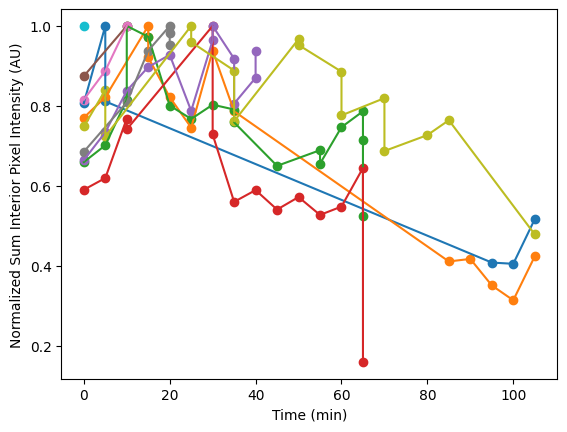

In [13]:
df=analyze_signal(csv_20251212, plot_graph=True)

In [104]:
df[df['ROI_ID']==26]

,Unnamed: 0,ROI_ID,frame,y,x,radius,sum
53,53,26,2,170.0,97.0,5.0,11.716156
397,397,26,12,173.0,90.0,5.0,7.485379
520,520,26,15,175.0,95.0,5.0,5.770909
560,560,26,16,174.0,95.0,5.0,6.197705
599,599,26,17,174.0,94.0,5.0,6.884158
601,601,26,17,326.0,88.0,5.0,6.941584
644,644,26,18,327.0,87.0,5.0,7.228992
648,648,26,18,278.0,324.0,5.0,7.323530
651,651,26,18,209.0,387.0,5.0,5.930673
700,700,26,19,209.0,388.0,5.0,5.178339
